# <span style="color:blue;font-weight:bold;font-size:1.1em">Day 7: Exploratory Data Analysis</span>
## <span style="color:blue;font-weight:bold;font-size:1.1em">Focusing on</span><center><span style="color:red;font-weight:bold;font-size:1.1em">1 Numeric Variable</span></center>


In this notebook we will cover:

- Exploratory Data Analysis (EDA) with a numeric data set.
- Review of bar graphs, bar charts, and histograms and their role in EDA.
- Review how to make and interpret boxplots.
- Creating, understanding and using side-by-side or overlapping graphs when comparing 2 groups.

In [405]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import seaborn as sns
import scipy.stats as stats
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")

## Read in a CSV data file from the web.
sky = Table.read_table('skyscrapers.csv')
top_movies = Table.read_table('top_movies_2017.csv')
pers = Table.read_table('http://faculty.ung.edu/rsinn/personality.csv')
births = Table.read_table('https://faculty.ung.edu/rsinn/data/baby.csv')
survey = Table.read_table('welcome_survey_v1.csv')

In [407]:
def describe(data, var = None):
  if isinstance(data, Table):
    data = data.column(var)
  names = np.array(["mean", "std", "n", " : : ", "min", "Q1", "median", "Q3", "max", "IQR"])
  values = np.array([round(np.mean(data),1), round(stats.tstd(data),2), len(data) - 1, "", min(data), np.percentile(data, 25), np.median(data), np.percentile(data, 75), max(data), stats.iqr(data)])
  tab = Table().with_columns('Names', names, 'Values', values)  ;  transposed_tab = Table().with_columns( zip(tab.column('Names'), tab.column('Values')) ).show()
  return

def describes(data, num, group):
  dat = data.column(num)  ;  group_var = data.column(group)  ;  groups = np.unique(group_var)  ;  rows = []  ;  tab = Table(["mean", "std", "n", " : : ", "min", "Q1", "median", "Q3", "max", "IQR"])
  for g in groups:
    # Filter data for the current group
    sub_dat = dat[group_var == g]  ;    rows = [g, round(np.mean(sub_dat), 1), round(stats.tstd(sub_dat), 2), len(sub_dat) - 1, min(sub_dat), np.percentile(sub_dat, 25), np.median(sub_dat), np.percentile(sub_dat, 75), max(sub_dat), stats.iqr(sub_dat)]        
    tab = tab.with_row(rows)
  tab.show()
  return 

def box(data, num = None, sm = False):
  if isinstance(data, Table):
    df = data.to_df()  ;  sns.boxplot(data=df, y=num, width=0.45, showmeans=sm)  ;
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()  
  else:
    if num == True:
      sm = True  ;  num = 'Variable'
    if num == None:
      num = 'Variable'
    plots.figure(figsize=(6, 6))  ;  plots.boxplot(data, widths = 0.45, showmeans=sm)
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()
  return

def boxes(data, num, cat, sm = False):
  if not isinstance(data, Table):
    print("ERROR: First input must be table name.")
  else:
    df = data.to_df()  ;  sns.boxplot(data=data, x=cat, y=num, width=0.75, showmeans=sm)
    plots.title(f'Boxplot of {num} Grouped by {cat}')  ;  plots.show()
  return

def density(data, num = None):
  if isinstance(data, Table):
    sns.kdeplot( data = data.column(num), bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  else:
    if num == None:
      num = 'Variable'  ;  sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
    else:
      sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  return

def densities(tab, var, group_var):
  groups = tab.column(group_var) ;  unique_groups = np.unique(groups)  ;  plots.figure()
  for g in unique_groups:
    # Filter data for the current group
    mask = (groups == g)
    x = tab.column(var)[mask]   
    # Calculate KDE for the group subset
    kde = gaussian_kde(x)
    x_grid = np.linspace(x.min() - 1, x.max() + 1, 512)  ;    plots.plot(x_grid, kde(x_grid), label=str(g))   
  plots.title(f'Density Plot of {var} by {group_var}')  ;  plots.xlabel(f'{var}')  ;  plots.ylabel('Density')
  plots.legend()  ;  plots.show()
  return




## <span style="color:blue;font-weight:bold;font-size:1.1em">1. Key Questions for EDA</span>

With explaroty data analysis we with to determine:

- **Shape?**
- **Outliers?**
- **Skew?**

The latter 2 go together as the <span style="color:red;font-weight:bold;font-size:1.1em">majority of the outliers tend to be in the direction of skew</span>, if there is any.

### <span style="color:blue;font-weight:bold;font-size:1.1em">Example 1</span>
#### <span style="color:blue;font-weight:bold;font-size:1.1em">Determining the Shape of the Distribution</span>
We typically use a <span style="color:red;font-weight:bold;font-size:1.1em">histogram or a density plot to determine shape</span>. **Histograms** are traditionally the go-to, but **density plots** hold up better when the distribution has an awkward shape. Below, we see a histogram which is quite good at showing the shape qualities of the distribution.

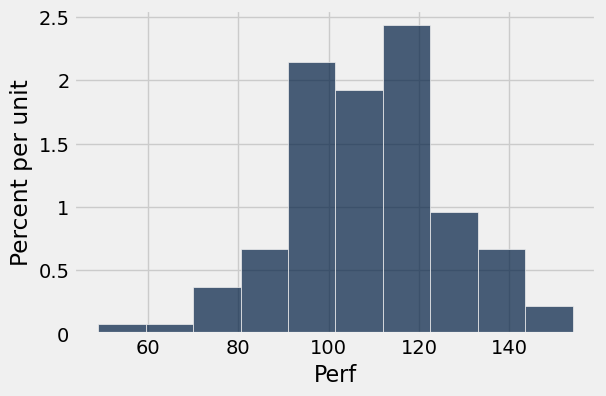

In [408]:
pers.hist('Perf')

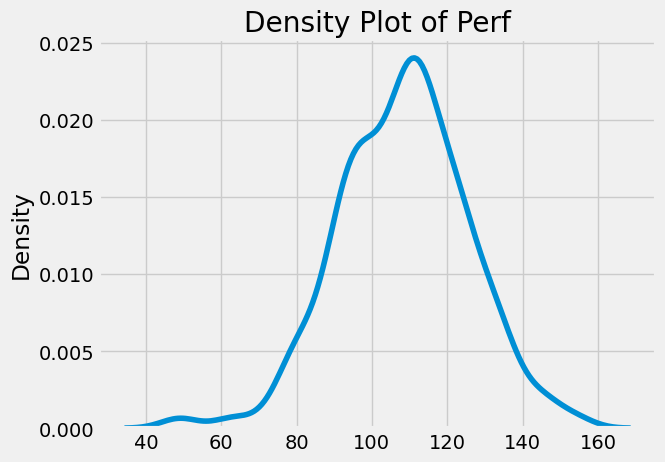

In [409]:
density(pers, 'Perf')

### <span style="color:blue;font-weight:bold;font-size:1.1em">Conclusion about Shape for Example 1</span>

**The data appears to be approximately normal (bell-shaped) with a slight skew to the left. (The skew is in the direction of the longer tail.)**

#### <span style="color:red;font-weight:bold;font-size:1.1em">Next Step: To determine skew and understand what outliers exist and where, we check a box plot:</span>

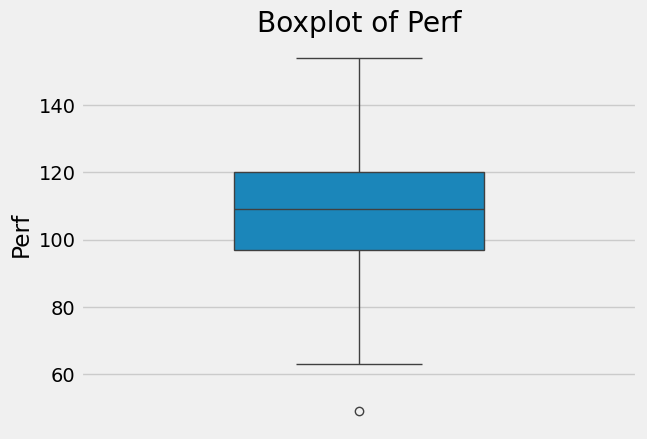

In [410]:
box(pers,'Perf')

We see that the tails of the distribution are approximately even with one outlier to the left. This tracks with a slight skew to the left.

#### <span style="color:blue;font-weight:bold;font-size:1.1em">Let's gather the descriptive statistics:</span>

In [411]:
describe(pers, 'Perf')

mean,std,n,: :,min,Q1,median,Q3,max,IQR
108.3,17.25,128,,49,97.0,109.0,120.0,154,23.0


#### <span style="color:blue;font-weight:bold;font-size:1.1em">Standard Descriptives:</span>
- Mean = 108.3
- Standard Deviation = 17.25
- N = 128

#### <span style="color:blue;font-weight:bold;font-size:1.1em">5-Number Summary:</span>
- Min = 49
- Q1 (25th percentil) = 97
- Median = 109
- Q3 (75th percentil) = 120
- Max = 154

##### <span style="color:red;font-weight:bold;font-size:1.1em">The mean (108.3) is slightly less than the median (109) which often occcurs with left-skewed distributions.</span>

#### <span style="font-weight:bold;font-size:1.1em">Note that a <span style="color:blue">box plot</span> is a visualization of the 5-Number Summary</span>

### <span style="color:blue;font-weight:bold;font-size:1.1em">EDA: Conclusions from Example 1</span> 

We find the data to  be <span style="font-weight:bold;font-size:1.1em">approximately normally distributed</span> (bell-shaped) with a single outlier to the left and a <span style="font-weight:bold;font-size:1.1em">slight skew to left</span>.

### <span style="font-size:1.1em">Practice Question: perform an EDA on the <span style="color:red">Birth Weight</span> variable in the <span style="color:red">births</span> table.</span>

In [412]:
descriptives = ...

In [413]:
histogram = ...

In [414]:
boxplot = ...

In [415]:
horiz_bar_chart_smokingstatus = ...

### <span style="font-weight:bold;font-size:1.1em">Analaysis of the Birth Weight distribution</span>

*Write your analysis statements here, replacing this text ...*

### <span style="font-weight:bold;font-size:1.1em">Practice Question: create a Pareto chart on the <span style="color:red">Studio</span> variable of the <span style="color:red">top_movies</span> table.</span> 

The Pareto chart can highlight trends in a distribution based upon a grouping table.

In [416]:
studios_grouping_table = ...

In [417]:
studios_sorted = ...

In [418]:
studios_Pareto = ...

### <span style="font-weight:bold;font-size:1.1em">Practice Question: perform an EDA on the <span style="color:red">Conscientiousness</span> data array given below.</span>

In [443]:
conscientious = make_array(23.3, 8.5, 14.1, 17.4, 26.4, 13.2, 24.5, 18, 16.3, 15.1, 13.1, 16.9, 20.9, 9.2, 18.8, 19, 16, 
     15.1, 16.6, 18.2, 19.3, 16.6, 16.3, 16.9, 7.8, 7.1, 11.5, 14.7, 26.7, 16.5, 16.5, 20.5, 20.7, 15.2, 21, 20.7, 16.7,
     20.9,  22.5,  12.6)

In [444]:
descriptives_con = ...

In [445]:
density_plot_con = ...

In [446]:
box_plot_con = ...

### <span style="font-weight:bold;font-size:1.1em">Analaysis of the Conscientiousness distribution</span>

*Write your analysis statements here, replacing this text ...*

## <span style="color:blue;font-weight:bold;font-size:1.1em">2. Histograms, Bins, and Density Plots</span>

We hope to make sense of the following:
- **Bins** are the equal intervals along the $x$-axis (width of bars).
- **Histograms** can appear very different depending upon the bins chosen.
- Users can **choose their own bins** overriding the Python defaults.
- **Density Plots** do not require binning since they already provide a more granular look at the distribution.

## <span style="font-size:1.1em">Practice Question: Add an <span style="color:red">Age</span> column to the top_movies table.</span>

In [423]:
year_array = top_movies.column('Year')
age_array = 2026 - year_array
top_movies_age = top_movies.with_column('Age', age_array)

In [424]:
top_movies_age

Title,Studio,Gross,Gross (Adjusted),Year,Age
Gone with the Wind,MGM,198676459,1796176700,1939,87
Star Wars,Fox,460998007,1583483200,1977,49
The Sound of Music,Fox,158671368,1266072700,1965,61
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982,44
Titanic,Paramount,658672302,1204368000,1997,29
The Ten Commandments,Paramount,65500000,1164590000,1956,70
Jaws,Universal,260000000,1138620700,1975,51
Doctor Zhivago,MGM,111721910,1103564200,1965,61
The Exorcist,Warner Brothers,232906145,983226600,1973,53
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937,89


## <span style="font-size:1.1em">Make a histogram based upon the <span style="color:red">Age</span> column</span>.

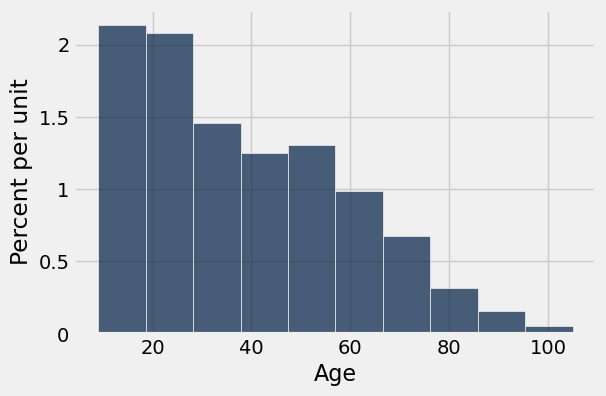

In [425]:
top_movies_age.hist('Age')

## <span style="font-size:1.1em">Try different bin widths like <span style="color:red">25</span> or <span style="color:red">15</span> or <span style="color:red">10</span>.</span>

The example below has a dissasterous bin width of 50 which clearly doesn't work out well at all.

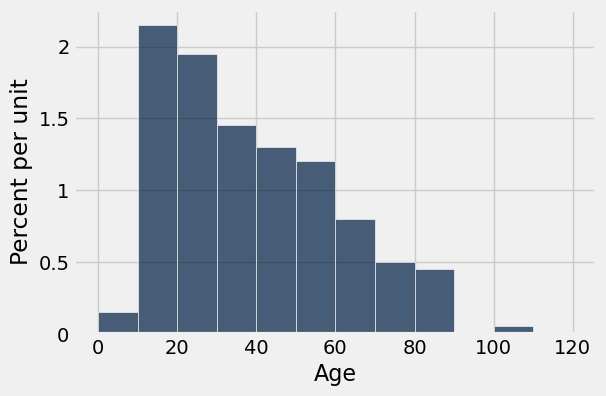

In [426]:
top_movies_age.hist('Age', bins = np.arange(0, 126, 10))

## <span style="font-size:1.1em">While histograms may appear awkward, try a density plot to compare</span>.

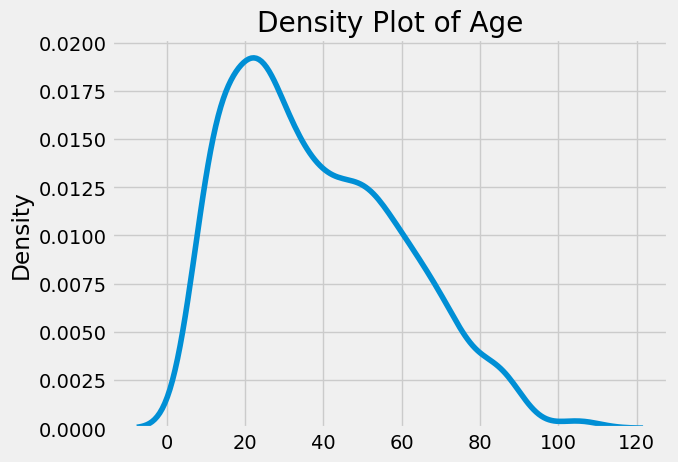

In [427]:
density(top_movies_age, 'Age')

## <span style="font-weight:bold;font-size:1.1em">Reflection Question:</span><span style="font-size:1.1em"> Compare default Python histogram to one with bin widths of 10, and compare both histograms to a density plot</span>.

What are the advantages and disadvatages of each?

Please note that the example above is a bad example.  On a histogram, bins should be the **same** size.  Now, let's look at another example showing the impact of bins.  

### The impact of bins ###

## <span style="font-weight:bold;font-size:1.1em">Practice Question:</span> <span style="font-size:1.1em">Create a histogram using the <span style="color:red">survey</span> table and the <span style="color:red">Hours of Sleep</span> column.</span>

<span style="color:red">Use the bins provided below.</span>

In [428]:
survey = Table.read_table('welcome_survey_v1.csv')
survey.show(3)

Extraversion,Number of textees,Hours of sleep,Handedness,Pant leg,Sleep position
4,6,4,Both,I don't know,On your back
8,6,7,Both,I don't know,On your back
9,6,7,Both,I don't know,On your back


In [429]:
sleep_bins = np.arange(4, 12, 0.5)

In [430]:
survey_sleep_hist = ...

In [431]:
# A different look emerges.
sleep_bins2 = np.arange(4,12, 1)
survey_sleep_hist2 = ...

In [432]:
# Compare a density plot.

survey_sleep_density = ...

## <span style="color:blue;font-weight:bold;font-size:1.1em">3. Box Plots</span>

Box plots provide a graphical display of the <span style="font-size:1.1em;font-weight:bold;color:red">Five Number Summary</span>.
- The minimum
- The $25^{th}$ percentile, $Q_1$
- The $50^{th}$ percentile, the median
- The $75^{th}$ percentile, $Q_3$
- The maximum

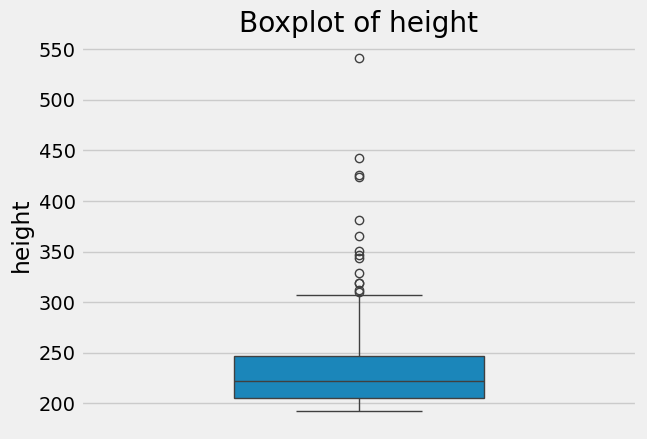

In [433]:
box(sky, 'height')

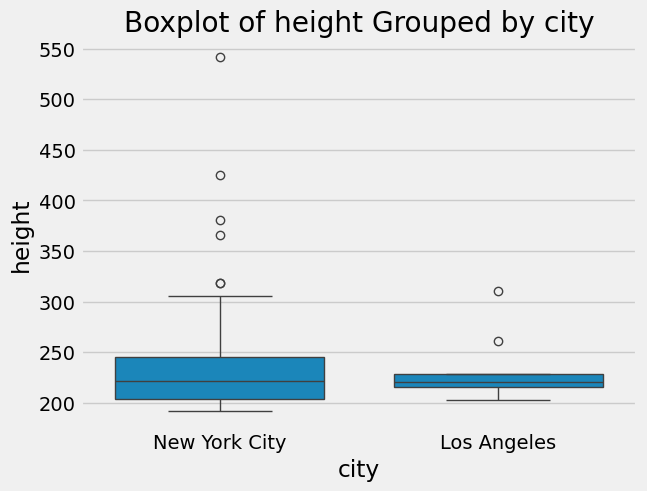

In [434]:
sky2 = sky.where('city', are.contained_in('Los Angeles New York City'))
boxes(sky2, 'height','city')

### Can we also display the mean on a boxplot? ###

Yes, if you set the value of **showmeans** equal to True.  

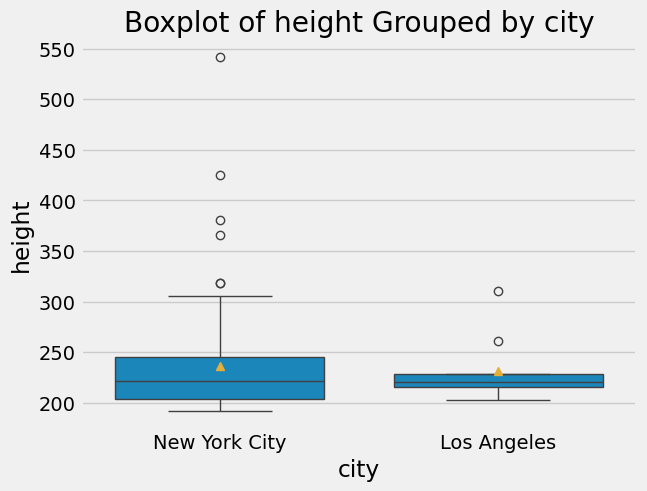

In [435]:
boxes(sky2, 'height','city', True)

## Comparing two groups numerically ##

We can use side-by-side boxplots to visually compare two groups.

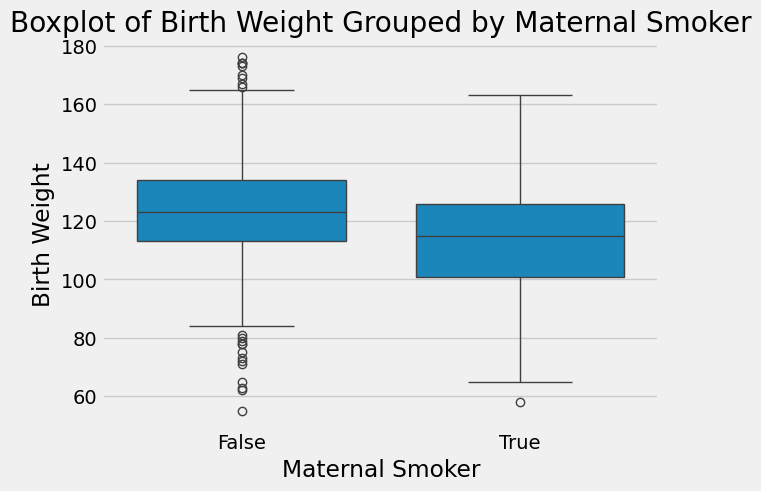

In [436]:
boxes(births, 'Birth Weight', 'Maternal Smoker')

## <span style="color:blue;font-weight:bold;font-size:1.1em">4. Comparing Multiple Groups</span>

Sometimes, we use <center><span style="color:purple;font-weight:bold;font-size:1.1em">overlapping histograms</span></br> or </br><span style="color:purple;font-weight:bold;font-size:1.1em">side-by-side boxplots</span></center></br>as is shown using the **galton** table below, an early study of how parents' heights affected the adult heights of their children.

In [437]:
galton = Table.read_table('galton.csv')

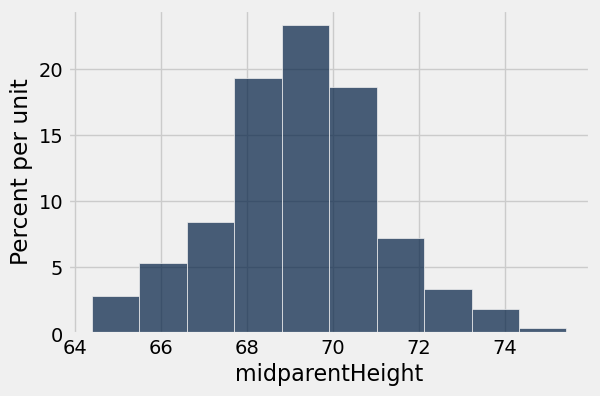

In [438]:
galton.hist('midparentHeight')

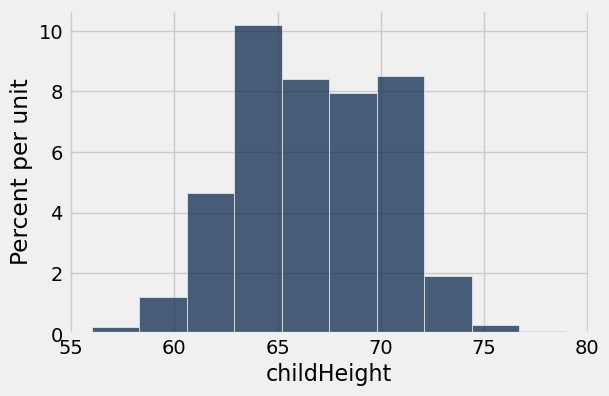

In [439]:
galton.hist('childHeight')

#### <span style="color:blue;font-weight:bold;font-size:1.1em">What part of this histogram is the children with heights above 70 inches?</span>

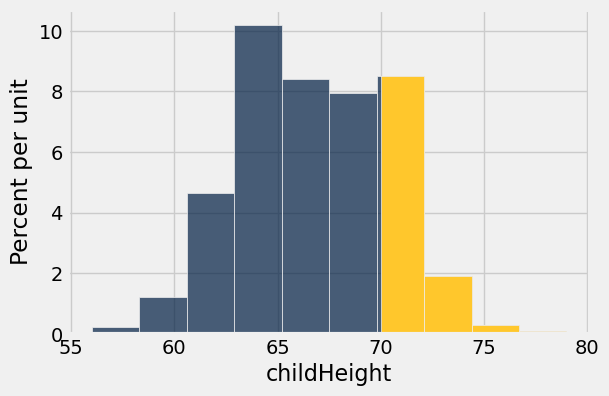

In [440]:
galton.hist('childHeight', left_end=70)

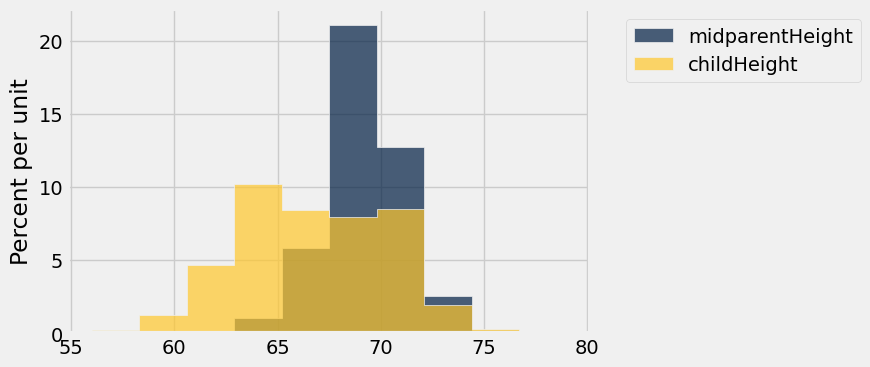

In [441]:
galton.hist('midparentHeight', 'childHeight')

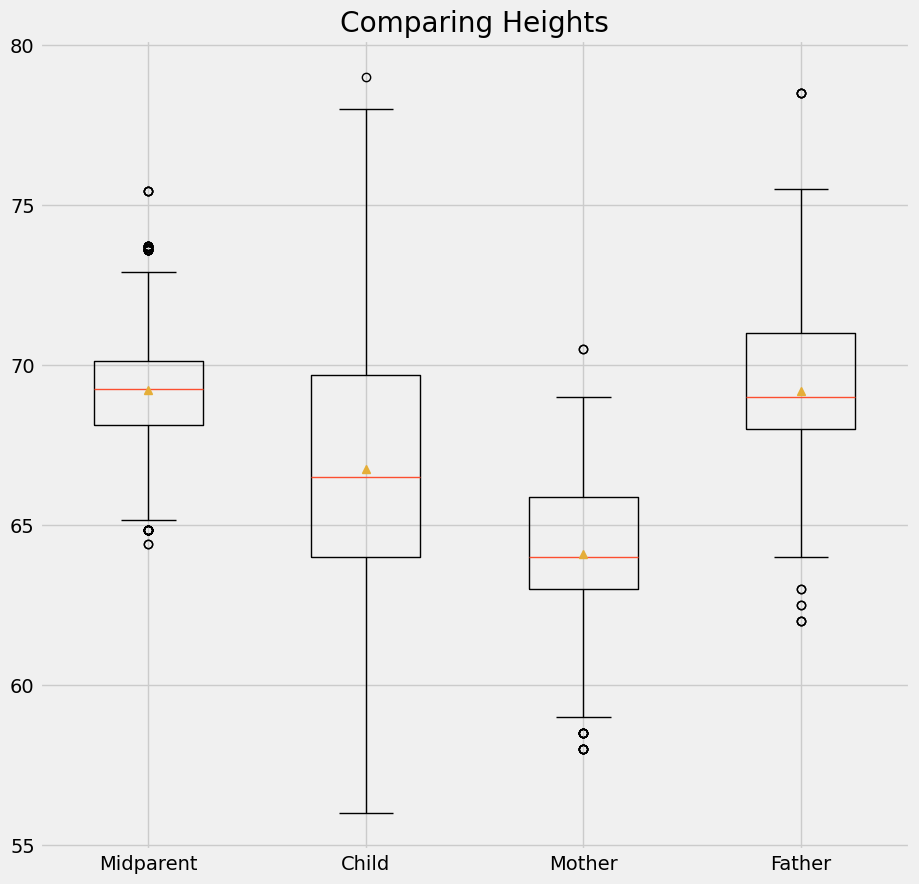

In [442]:
ticks=make_array(2.5, 3.5, 4.5, 5.5)
labels=make_array("Midparent", "Child", "Mother", "Father")

plots.figure(figsize=(10, 10))
plots.boxplot(galton.column("midparentHeight"), widths=.5, positions= make_array(ticks.item(0)), showmeans=True)
plots.boxplot(galton.column("childHeight"), widths=.5, positions=make_array(ticks.item(1)), showmeans=True)
plots.boxplot(galton.column("mother"), widths=.5, positions=make_array(ticks.item(2)), showmeans=True)
plots.boxplot(galton.column("father"), widths=.5, positions=make_array(ticks.item(3)), showmeans=True)
plots.xticks(ticks, labels)
plots.title("Comparing Heights");